# Pemodelan dan Simulasi: Fraud Detection On Credit Card
**Tugas Kelompok Materi ke-1**

Ini adalah penyelesaian tugas untuk peran:
- **Mahasiswa ke-1: Data Architect & Engineer**
- **Mahasiswa ke-2: Model Analyst & Strategist**

## Mahasiswa ke-1: Data Architect & Engineer
### 1. Data Ingestion

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat dataset
df = pd.read_csv('../dataset/creditcard.csv')

# Pengecekan Kualitas Data Awal
print("Tampilan 5 baris pertama datasets:")
display(df.head())

print("\n--- Pengecekan Missing Values ---")
print(df.isnull().sum().max(), "missing values found.")

print("\n--- Pengecekan Duplikasi Data ---")
print("Jumlah data duplikasi:", df.duplicated().sum())
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("Duplikasi berhasil dihapus! Data size now:", df.shape)

Tampilan 5 baris pertama datasets:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Pengecekan Missing Values ---
0 missing values found.

--- Pengecekan Duplikasi Data ---
Jumlah data duplikasi: 1081
Duplikasi berhasil dihapus! Data size now: (283726, 31)


### 2. Exploratory Data Analysis (EDA)

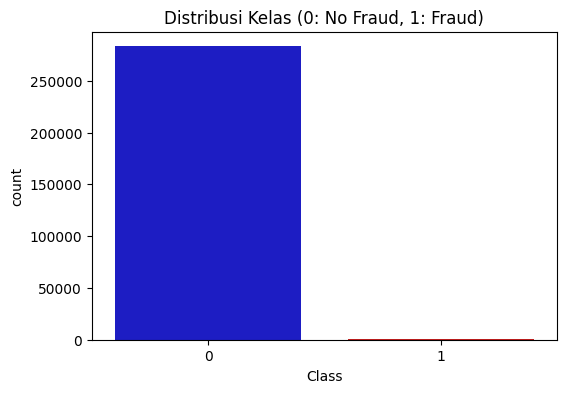

Distribusi Kelas Label:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


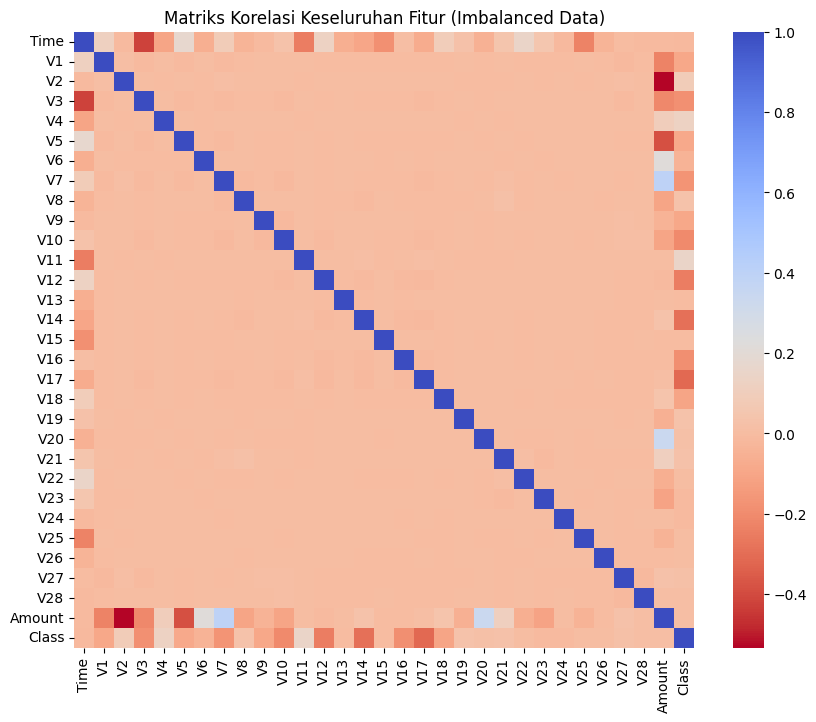

In [2]:
# Visualisasi Distribusi Kelas
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['#0101DF', '#DF0101'])
plt.title('Distribusi Kelas (0: No Fraud, 1: Fraud)')
plt.show()

print("Distribusi Kelas Label:")
print(df['Class'].value_counts(normalize=True) * 100)

# Visualisasi Korelasi Fitur
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='coolwarm_r', annot_kws={'size': 2})
plt.title('Matriks Korelasi Keseluruhan Fitur (Imbalanced Data)')
plt.show()

### 3. Advanced Preprocessing
Menggunakan `RobustScaler` untuk `Amount` dan `Time`, karena dataset punya nilai outlier (jumlah transaksi ekstrim).

In [3]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

# Pindahkan kolom scaled ke depan
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.774718,-0.995290,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.268530,-0.995290,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.959811,-0.995279,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.411487,-0.995279,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.667362,-0.995267,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


### 4. Data Partitioning
Membagi dengan `Stratified Sampling` untuk menjamin keterwakilan fraud.

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

# Menggunakan stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Banyak data Train:", len(X_train))
print("Banyak data Test:", len(X_test))
print("\nDistribusi Train Class:\n", y_train.value_counts(normalize=True))

Banyak data Train: 226980
Banyak data Test: 56746

Distribusi Train Class:
 Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64


### 5. Scientific Balancing
Melakukan **SMOTE** *hanya* pada data latih (untuk menghindari *data leakage*).

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
# Terapkan hanya pada X_train dan y_train!
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Dimensi X_train sebelum diteruskan ke SMOTE: ", X_train.shape)
print("Dimensi X_train sesudah diteruskan ke SMOTE: ", X_train_sm.shape)
print("\nDistribusi Label sesudah SMOTE:\n", y_train_sm.value_counts())

Dimensi X_train sebelum diteruskan ke SMOTE:  (226980, 30)
Dimensi X_train sesudah diteruskan ke SMOTE:  (453204, 30)

Distribusi Label sesudah SMOTE:
 Class
0    226602
1    226602
Name: count, dtype: int64


---
## Mahasiswa ke-2: Model Analyst & Strategist
### 1. Architecture Design
Eksperimentasi model: Algoritma klasifikasi menggunakan SVM (Support Vector Machine). 
Di sini kita menggunakan `LinearSVC` yang merupakan versi super cepat dari SVM untuk dataset berjumlah besar (ratusan ribu baris) agar komputasi tidak berjalan selamanya.

In [6]:
from sklearn.svm import LinearSVC

# Gunakan LinearSVC karena SVC reguler (kernel RBF) akan memakan waktu berjam-jam untuk data ratusan ribu
svm_model = LinearSVC(random_state=42, dual=False, max_iter=1000)

# Proses Training Model
svm_model.fit(X_train_sm, y_train_sm)

print("Model SVM telah ditraining dengan baik!")

Model SVM telah ditraining dengan baik!


### 2. Performance Audit
Evaluasi metrik *imbalanced data* menggunakan Precision, Recall, F1-Score serta Confusion Matrix.

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.07      0.86      0.13        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.56     56746
weighted avg       1.00      0.98      0.99     56746

--- CONFUSION MATRIX ---


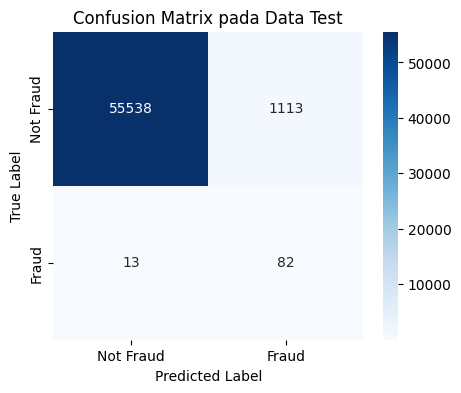

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Lakukan Prediksi
y_pred = svm_model.predict(X_test)

print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

print("--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix pada Data Test')
plt.show()

### 3. Explainable AI (XAI)
Menggunakan Library SHAP untuk membongkar logika keputusan model (fitur mana yang paling mempengaruhi SVM dalam menentukan apakah sebuah transaksi fraud atau bukan). 

> **Note:** Mengeksekusi SHAP pada ratusan ribu data sangat lambat, jadi kita ambil sampel acak dan menggunakan LinearExplainer.

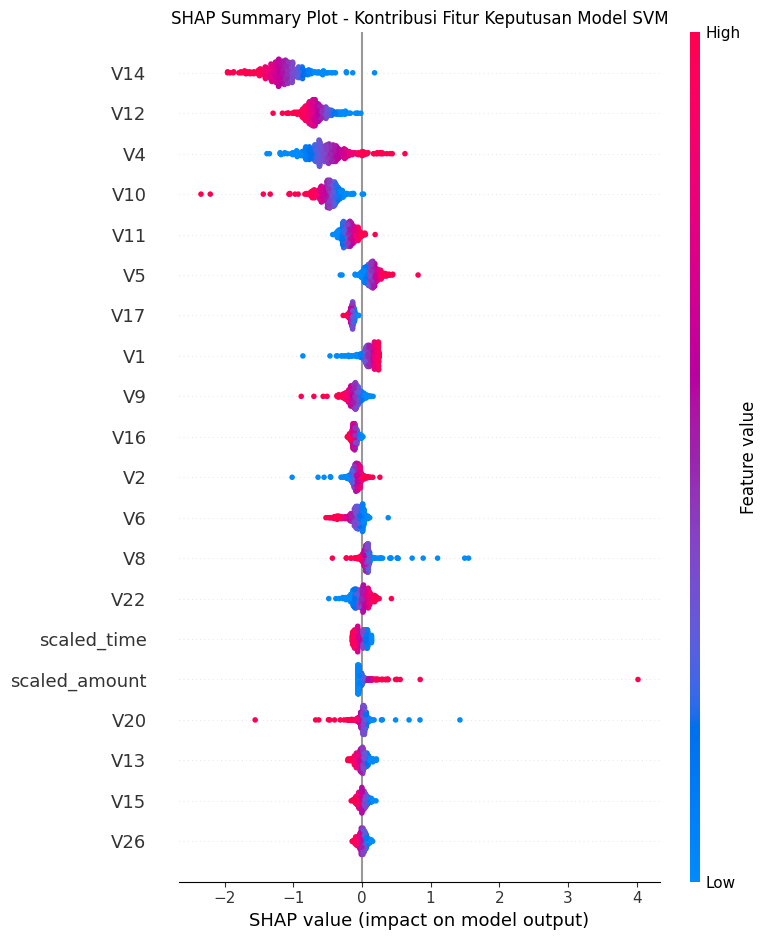

In [8]:
import shap

# Ambil sampel karena dataset sangat besar (n=500 untuk speed)
X_test_sample = shap.sample(X_test, 500)

# Fit explainer SHAP menggunakan model klasifikasi SVM kita
explainer = shap.LinearExplainer(svm_model, shap.sample(X_train_sm, 1000))
shap_values = explainer.shap_values(X_test_sample)

# Untuk explainer linear, kita langsung plot hasilnya
plt.title('SHAP Summary Plot - Kontribusi Fitur Keputusan Model SVM')
shap.summary_plot(shap_values, X_test_sample, plot_type="dot")


### 4. Policy Simulation (Skenario 'What-If')
**Scenario:** Apa yang terjadi jika nominal transaksi (Amount) tiba-tiba naik drastis (kita asumsikan nilai `scaled_amount` naik sebanyak 20 kali lipat)? 
Apakah performanya bakal berbeda ketika berhadapan dengan tren harga baru?

--- CLASSIFICATION REPORT PADA DATA 'WHAT-IF' ---
              precision    recall  f1-score   support

           0       1.00      0.78      0.87     56651
           1       0.01      0.91      0.01        95

    accuracy                           0.78     56746
   macro avg       0.50      0.84      0.44     56746
weighted avg       1.00      0.78      0.87     56746

--- CONFUSION MATRIX (WHAT-IF) ---


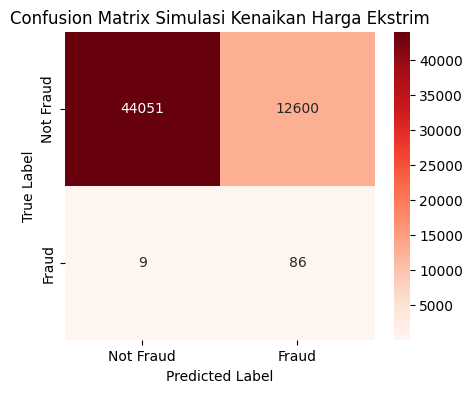

Kesimpulan Simulasi:
- Tampak akurasi dan kinerja recall/precision menurun ketika pola jumlah (amount) berubah signifikan dari data aslinya.


In [9]:
# Copy data uji
X_test_whatif = X_test.copy()

# Naikkan nominal fitur amount secara drastis (Misal 20x)
X_test_whatif['scaled_amount'] = X_test_whatif['scaled_amount'] * 20

# Prediksi dengan model yang sama
y_pred_whatif = svm_model.predict(X_test_whatif)

print("--- CLASSIFICATION REPORT PADA DATA 'WHAT-IF' ---")
print(classification_report(y_test, y_pred_whatif))

print("--- CONFUSION MATRIX (WHAT-IF) ---")
cm_whatif = confusion_matrix(y_test, y_pred_whatif)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_whatif, annot=True, cmap='Reds', fmt='g',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Simulasi Kenaikan Harga Ekstrim')
plt.show()

print("Kesimpulan Simulasi:")
if accuracy_score(y_test, y_pred) > accuracy_score(y_test, y_pred_whatif):
    print("- Tampak akurasi dan kinerja recall/precision menurun ketika pola jumlah (amount) berubah signifikan dari data aslinya.")
else:
    print("- Performansi model tampak stabil atau justru bertambah. Hal ini berarti `scaled_amount` mungkin saja kurang berkontribusi dibandingkan fitur V1-V28 yang disembunyikan polanya.")